# Diffusion Models
---

## Overview

Diffusion models define a forward process that gradually corrupts data with Gaussian noise, then learn to reverse it.

Given $\mathbf{x}_0 \sim q(\mathbf{x}_0)$, the forward Markov chain is

$$
q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}\!\left(\mathbf{x}_t;\, \sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\, \beta_t \mathbf{I}\right)
$$

With cumulative products $\bar{\alpha}_t = \prod_{s=1}^t (1-\beta_s)$ this collapses to a single step:

$$
q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}\!\left(\mathbf{x}_t;\, \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0,\, (1-\bar{\alpha}_t)\mathbf{I}\right)
$$

A neural network $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ is trained to predict the added noise, minimising

$$
\mathcal{L} = \mathbb{E}_{t,\mathbf{x}_0,\boldsymbol{\epsilon}}\!\left[\|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\|^2\right]
$$


In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm

torch.manual_seed(0)
np.random.seed(0)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---

## Dataset: 2D Spiral


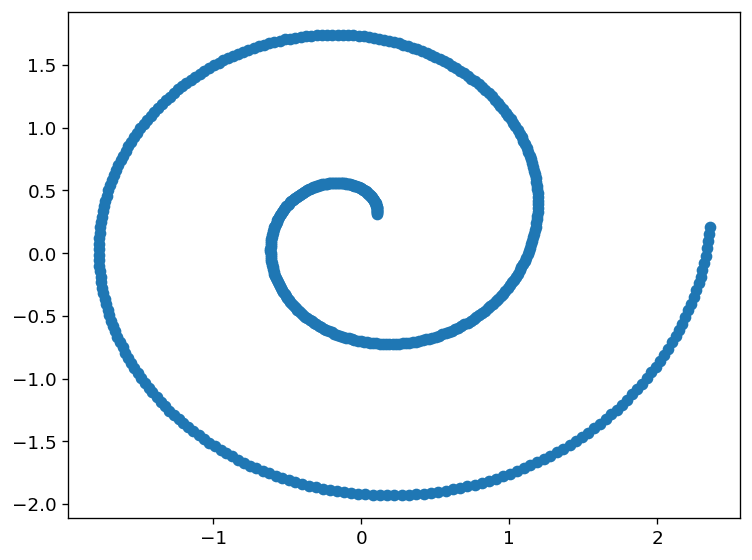

In [2]:
def make_spiral(n=500):
    theta = torch.linspace(torch.pi / 4, 4 * torch.pi, n)
    X = torch.stack([ theta * torch.cos(theta),  theta * torch.sin(theta)], dim=1)
    X = (X - X.mean(0)) / X.std(0) 
    return X

X = make_spiral()

plt.scatter(X[:,0], X[:,1])
plt.tight_layout()
plt.show()

---

## DDPM: Forward Noising Process

We define a linear schedule for the variance $\beta_1,..., \beta_T$ of the noise. Then we define:

$$
\alpha_t = 1 - \beta_t, \qquad \bar{\alpha}_t = \prod_{s=1}^t \alpha_s
$$

The closed-form forward sample is

$$
\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
$$

At $t = T$, $\bar{\alpha}_T \approx 0$ so $\mathbf{x}_T \approx \mathcal{N}(\mathbf{0}, \mathbf{I})$.

In [31]:
T = 500
betas      = torch.linspace(1e-4, 1e-2, T)
alphas     = 1.0 - betas                  
alphas_bar = torch.cumprod(alphas, dim=0)

In [ ]:
print(alphas.shape)
print(betas.shape)
print(alphas_bar.shape)
print(X.shape)


torch.Size([500])
torch.Size([500])
torch.Size([500])
torch.Size([500, 2])
tensor(0.9999)


In [34]:
def q_sample(x0, t):
    noise = torch.randn_like(x0)

    sqrt_ab = torch.sqrt(alphas_bar[t]).unsqueeze(1)
    sqrt_one_minus_ab = torch.sqrt(1 - alphas_bar[t]).unsqueeze(1)

    xt = sqrt_ab * x0 + sqrt_one_minus_ab * noise
    return xt, noise

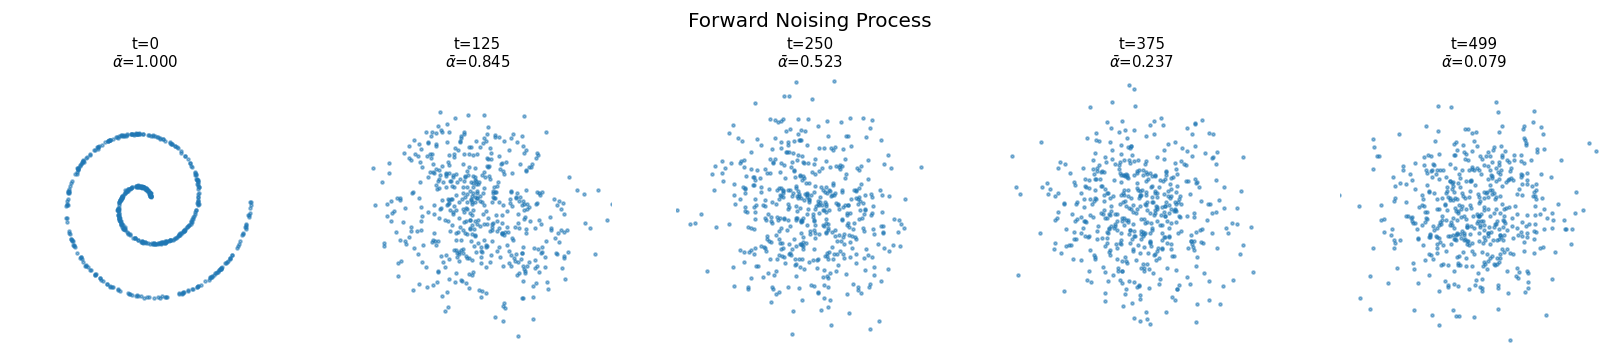

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
snapshots = [0, T//4, T//2, 3*T//4, T-1]
idx = torch.randint(0, len(X), (500,))
x0_sub = X[idx]

for ax, t_val in zip(axes, snapshots):
    t_vec = torch.full((500,), t_val, dtype=torch.long)
    xt, _ = q_sample(x0_sub, t_vec)
    ax.scatter(xt[:, 0].numpy(), xt[:, 1].numpy(), s=3, alpha=0.5)
    ab = alphas_bar[t_val].item()
    ax.set_title(f't={t_val}\n$\\bar{{\\alpha}}$={ab:.3f}', fontsize=9)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle('Forward Noising Process', fontsize=12)
plt.tight_layout(); plt.show()

---

## Denoising Network


In [36]:
class NoisePredictor(nn.Module):
    def __init__(self, hidden=64, T=100):
        super().__init__()
        self.T = T
        in_dim = 3
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt, t):
        t = t.reshape(-1,1)/self.T
        return self.net(torch.cat([xt, t], dim=1))

In [37]:
model = NoisePredictor()

---

## Training and Reverse Sampling

Training minimises:

$$
\mathcal{L} = \mathbb{E}_{t \sim \mathcal{U}[1,T],\, \mathbf{x}_0,\, \boldsymbol{\epsilon}}\!\left[\|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\|^2\right]
$$

Sampling iterates

$$
\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\right) + \sqrt{\beta_t}\,\mathbf{z}, \qquad \mathbf{z} \sim \mathcal{N}(\mathbf{0},\mathbf{I})
$$

with $\mathbf{z} = \mathbf{0}$ at $t = 1$.

In [116]:
T = 500

def train_ddpm(model, data, n_epochs=10000, batch_size=128, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    N = len(data)
    model.train()

    for epoch in range(n_epochs):
        idx = torch.randperm(N)[:batch_size]
        x0 = data[idx]
        t = torch.randint(0, T, (batch_size, ))

        xt, eps = q_sample(x0, t)

        loss = F.mse_loss(model(xt,t), eps)


        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())
        if (epoch+1) % 1000 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}')
    return losses


In [119]:
losses_ddpm = train_ddpm(model, X, 10000)

Epoch 1000/10000, Loss: 0.4690
Epoch 2000/10000, Loss: 0.4488
Epoch 3000/10000, Loss: 0.5815
Epoch 4000/10000, Loss: 0.4897
Epoch 5000/10000, Loss: 0.4125
Epoch 6000/10000, Loss: 0.3903
Epoch 7000/10000, Loss: 0.5026
Epoch 8000/10000, Loss: 0.4357
Epoch 9000/10000, Loss: 0.4709
Epoch 10000/10000, Loss: 0.4071


In [123]:
@torch.no_grad()

def ddpm_sample(model, n_samples=500, T = 500):
    model.eval()
    x = torch.randn(n_samples, 2)
    

    for t_val in range(T-1, -1, -1):
        t_vec = torch.full((n_samples,), t_val, dtype=torch.long)
        eps = model(x, t_vec)
        b = betas[t_val]
        ab = alphas_bar[t_val]
        a = alphas[t_val]

        x = 1/torch.sqrt(a) * (x - b/(torch.sqrt(1-ab)) * eps)

        if t_val > 0:
            x += torch.sqrt(b) * torch.randn_like(x)
    return x

In [124]:
ddpm_samples = ddpm_sample(model, n_samples=500, T=500)

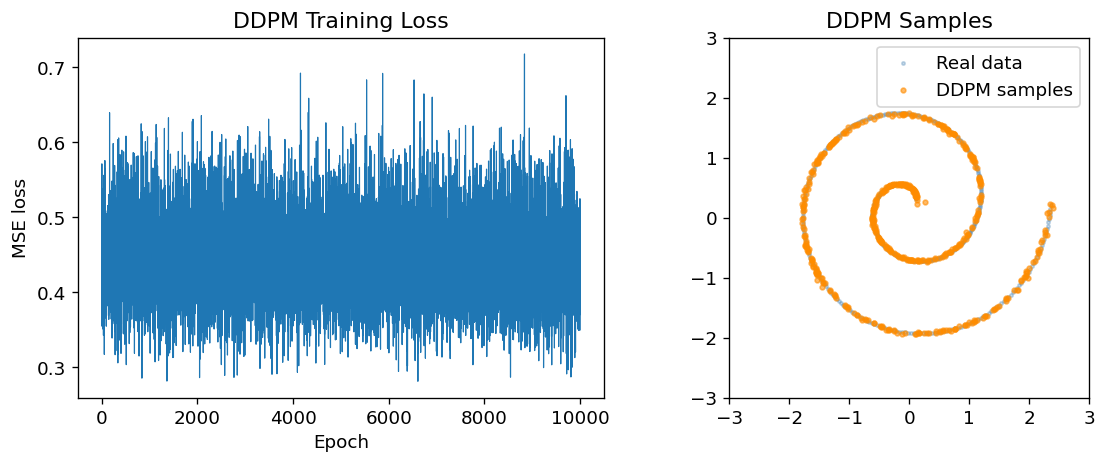

In [125]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(losses_ddpm, lw=0.7); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE loss'); axes[0].set_title('DDPM Training Loss')

axes[1].scatter(X[:, 0], X[:, 1], s=4, alpha=0.3, label='Real data', color='steelblue')
axes[1].scatter(ddpm_samples[:, 0], ddpm_samples[:, 1], s=8, alpha=0.6,
                label='DDPM samples', color='darkorange')
axes[1].set_title('DDPM Samples'); axes[1].legend()
axes[1].set_xlim(-3, 3); axes[1].set_ylim(-3, 3); axes[1].set_aspect('equal')
plt.tight_layout(); plt.show()

---

## Vector Fields

The trained noise predictor defines a velocity field at each time $t$. The deterministic part of the reverse step is

$$
\mathbf{x}_{t-1} = \mathbf{x}_t - \mathbf{v}_\theta(\mathbf{x}_t, t)\,\Delta t
$$

At high noise levels the field points globally toward the data manifold; at low noise levels it resolves fine structure.

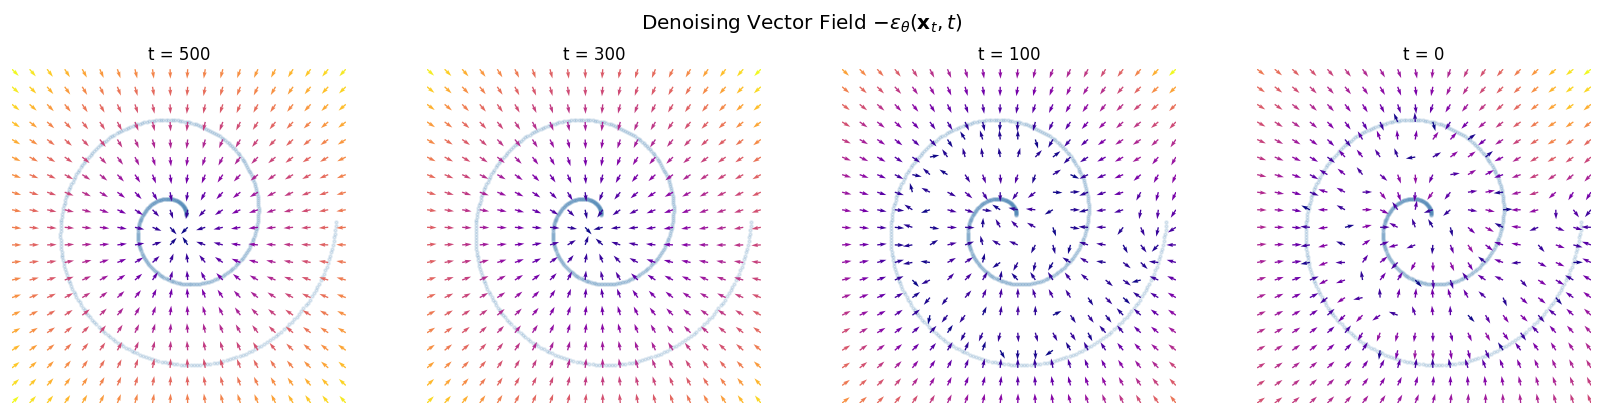

In [93]:
@torch.no_grad()
def plot_vector_field(model, timesteps=(500, 300, 100, 0), grid_size=20, lim=2.5):
    g = torch.linspace(-lim, lim, grid_size)
    gx, gy = torch.meshgrid(g, g, indexing='xy')
    grid = torch.stack([gx.flatten(), gy.flatten()], dim=1)  # (G^2, 2)

    fig, axes = plt.subplots(1, len(timesteps), figsize=(14, 3.5))
    for ax, t_val in zip(axes, timesteps):
        t_vec = torch.full((grid.shape[0],), t_val, dtype=torch.long)
        v = -model(grid, t_vec).numpy()               
        mag = np.hypot(v[:, 0], v[:, 1]) + 1e-8
        v_n = v / mag[:, None]               

        ax.scatter(X[:, 0], X[:, 1], s=3, alpha=0.15, color='steelblue')
        ax.quiver(grid[:, 0].numpy(), grid[:, 1].numpy(),
                  v_n[:, 0], v_n[:, 1],
                  mag, cmap='plasma', scale=35, width=0.004)
        ax.set_title(f't = {t_val}', fontsize=10)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect('equal'); ax.axis('off')

    plt.suptitle('Denoising Vector Field $-\\epsilon_\\theta(\\mathbf{x}_t, t)$', fontsize=12)
    plt.tight_layout(); plt.show()

plot_vector_field(model)

---

## DDIM: Deterministic Fast Sampling

Deterministic update that reuses the same $\boldsymbol{\epsilon}_\theta$:

$$
\mathbf{x}_{t-1} = \sqrt{\bar{\alpha}_{t-1}}\underbrace{\left(\frac{\mathbf{x}_t - \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)}{\sqrt{\bar{\alpha}_t}}\right)}_{\hat{\mathbf{x}}_0 \text{ prediction}}
+ \sqrt{1-\bar{\alpha}_{t-1}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)
$$

The same $\mathbf{x}_T$ always yields the same $\mathbf{x}_0$.

In [155]:
@torch.no_grad()
def ddim_sample(model, n_samples=500, n_steps=50):
    model.eval()
    step_seq = torch.linspace(T-1, 0, n_steps, dtype=torch.long)
    x = torch.randn(n_samples, 2)

    for i, t_val in enumerate(step_seq):
        t_vec = torch.full((n_samples,), t_val, dtype=torch.long)
        eps = model(x, t_vec)
        b = betas[t_val]
        ab = alphas_bar[t_val]
        a = alphas[t_val]

        x0 = x-torch.sqrt(1-ab) * eps / torch.sqrt(ab)
        if i < n_steps - 1:
            next_ab = alphas_bar[step_seq[i+1]]
            x = torch.sqrt(next_ab) * x0 + torch.sqrt(1-next_ab) * eps

            
    return x


In [158]:
n_steps_ddim = 50

ddim_samples = ddim_sample(model, n_steps=n_steps_ddim)

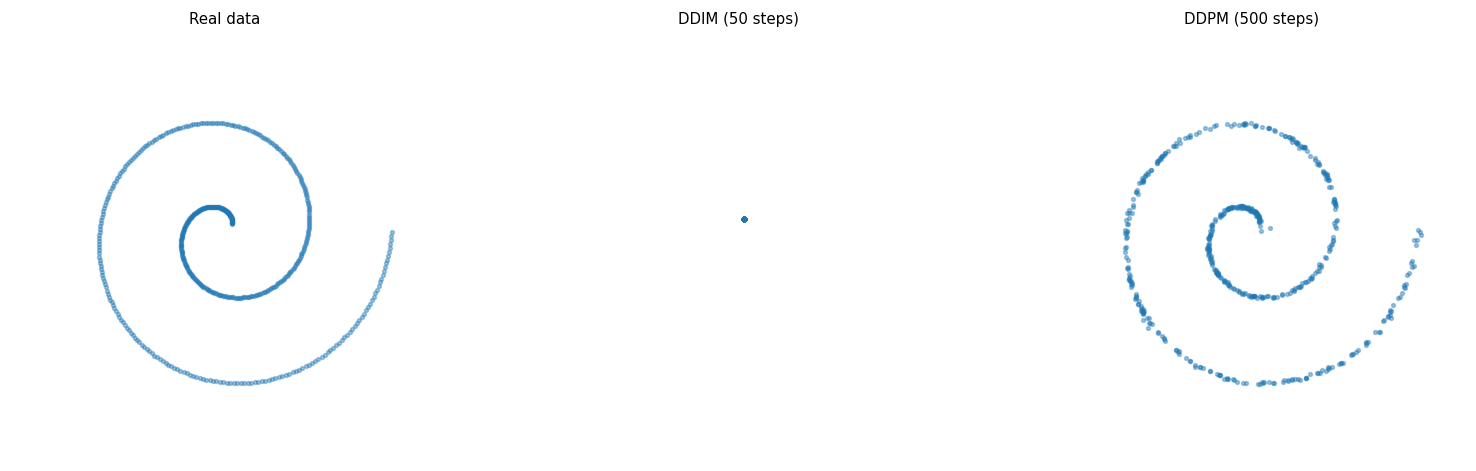

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = ['Real data', f'DDIM ({n_steps_ddim} steps)', f'DDPM ({T} steps)']
dsets  = [X, ddim_samples, ddpm_samples]


for ax, title, dat in zip(axes, titles, dsets):
    ax.scatter(dat[:, 0].numpy(), dat[:, 1].numpy(), s=5, alpha=0.4)
    ax.set_title(title, fontsize=9); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout(); plt.show()

---

## Classifier-Free Guidance (CFG)

So far our model samples unconditionally from the data distribution. In practice we usually want conditional generation: produce a sample from class $c$.

### Training

Train a single network that can act as both a conditional and an unconditional model. During training, replace the label $c$ with a special null token $\varnothing$ with probability $p \approx 0.1$:

$$
\mathcal{L} = \mathbb{E}_{t, \mathbf{x}_0, \boldsymbol{\epsilon}, c}\!\left[\|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t, c')\|^2\right], \qquad c' = \begin{cases} \varnothing & \text{with prob } p \\ c & \text{otherwise} \end{cases}
$$

The same network now learns both $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t, c)$ (conditional) and $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t, \varnothing)$ (unconditional).

### Guided sampling

At sample time we compute both predictions and extrapolate away from the unconditional one:

$$
\tilde{\boldsymbol{\epsilon}}(\mathbf{x}_t, t, c) = \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t, \varnothing) + w \cdot \bigl(\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t, c) - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t, \varnothing)\bigr)
$$

The guidance scale $w$ controls the strength of conditioning.


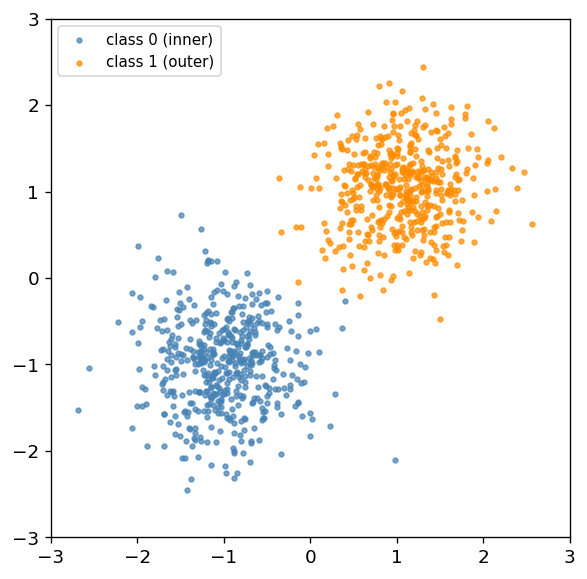

In [185]:
def make_spiral_2class(n=500):
    theta = torch.linspace(torch.pi / 4, 4 * torch.pi, n)
    X = torch.stack([theta * torch.cos(theta), theta * torch.sin(theta)], dim=1)
    X = (X - X.mean(0)) / X.std(0)
    r = X.norm(dim=1)
    y = (r > r.median()).long()   # 0 = inner half of spiral, 1 = outer half
    return X, y

def make_2spiral(n=500):
    theta = torch.linspace(torch.pi / 4, 4 * torch.pi, n)
    X1 = torch.stack([theta * torch.cos(theta), theta * torch.sin(theta)], dim=1)
    X2 = torch.stack([theta * torch.cos(theta + torch.pi), theta * torch.sin(theta + torch.pi)], dim=1)
    X = torch.cat([X1, X2], dim=0)
    X = (X - X.mean(0)) / X.std(0)
    y = torch.cat([torch.zeros(n, dtype=torch.long), torch.ones(n, dtype=torch.long)], dim=0)
    return X, y

# make a 2 clouds linearly separable
def make_2clouds(n=500):
    X1 = torch.randn(n, 2) * 0.5 + torch.tensor([-1, -1])
    X2 = torch.randn(n, 2) * 0.5 + torch.tensor([1, 1])
    X = torch.cat([X1, X2], dim=0)
    y = torch.cat([torch.zeros(n, dtype=torch.long), torch.ones(n, dtype=torch.long)], dim=0)
    return X, y

X, y = make_2clouds(n=500)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=8, alpha=0.7, color='steelblue', label='class 0 (inner)')
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=8, alpha=0.7, color='darkorange', label='class 1 (outer)')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [186]:
class CondNoisePredictor(nn.Module):
    def __init__(self, hidden=64, T=500, n_classes=2):
        super().__init__()
        self.T = T
        self.null_class = n_classes                       # index for unconditional
        self.label_emb = nn.Embedding(n_classes + 1, hidden)
        in_dim = 2 + 1 + hidden                           # xt, t, label
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt, t, y):
        t = t.reshape(-1, 1) / self.T
        emb = self.label_emb(y)
        return self.net(torch.cat([xt, t, emb], dim=1))

In [187]:
def train_cfg(model, data, labels, n_epochs=10000, batch_size=128, lr=1e-3, p_drop=0.3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    N = len(data)
    losses = []
    model.train()
    for epoch in range(n_epochs):
        idx = torch.randperm(N)[:batch_size]
        x0  = data[idx]
        yb  = labels[idx].clone()
        drop = torch.rand(batch_size) < p_drop
        yb[drop] = model.null_class
        t = torch.randint(0, T, (batch_size,))
        xt, eps = q_sample(x0, t)
        loss = F.mse_loss(model(xt, t, yb), eps)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

In [188]:
@torch.no_grad()
def ddpm_sample_cfg(model, target_class, n_samples=500, w=3.0):
    model.eval()
    x      = torch.randn(n_samples, 2)
    y_cond = torch.full((n_samples,), target_class, dtype=torch.long)
    y_null = torch.full((n_samples,), model.null_class, dtype=torch.long)
    for t_val in range(T - 1, -1, -1):
        t_vec = torch.full((n_samples,), t_val, dtype=torch.long)
        eps_c = model(x, t_vec, y_cond)
        eps_u = model(x, t_vec, y_null)
        eps   = eps_u + w * (eps_c - eps_u)
        b, ab, a = betas[t_val], alphas_bar[t_val], alphas[t_val]
        x = (1 / a.sqrt()) * (x - b / (1 - ab).sqrt() * eps)
        if t_val > 0:
            x = x + b.sqrt() * torch.randn_like(x)
    return x

In [189]:
model_cfg = CondNoisePredictor(T=T, n_classes=2)
losses    = train_cfg(model_cfg, X, y)

samples_c0_w3 = ddpm_sample_cfg(model_cfg, target_class=0, w=3.0)
samples_c1_w3 = ddpm_sample_cfg(model_cfg, target_class=1, w=3.0)

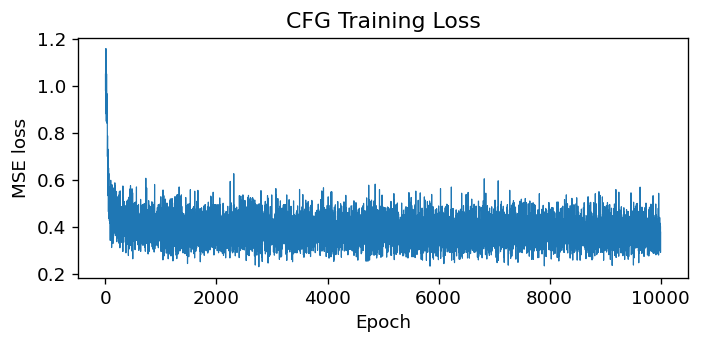

In [190]:
plt.figure(figsize=(6, 3))
plt.plot(losses, lw=0.7)
plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.title('CFG Training Loss')
plt.tight_layout(); plt.show()

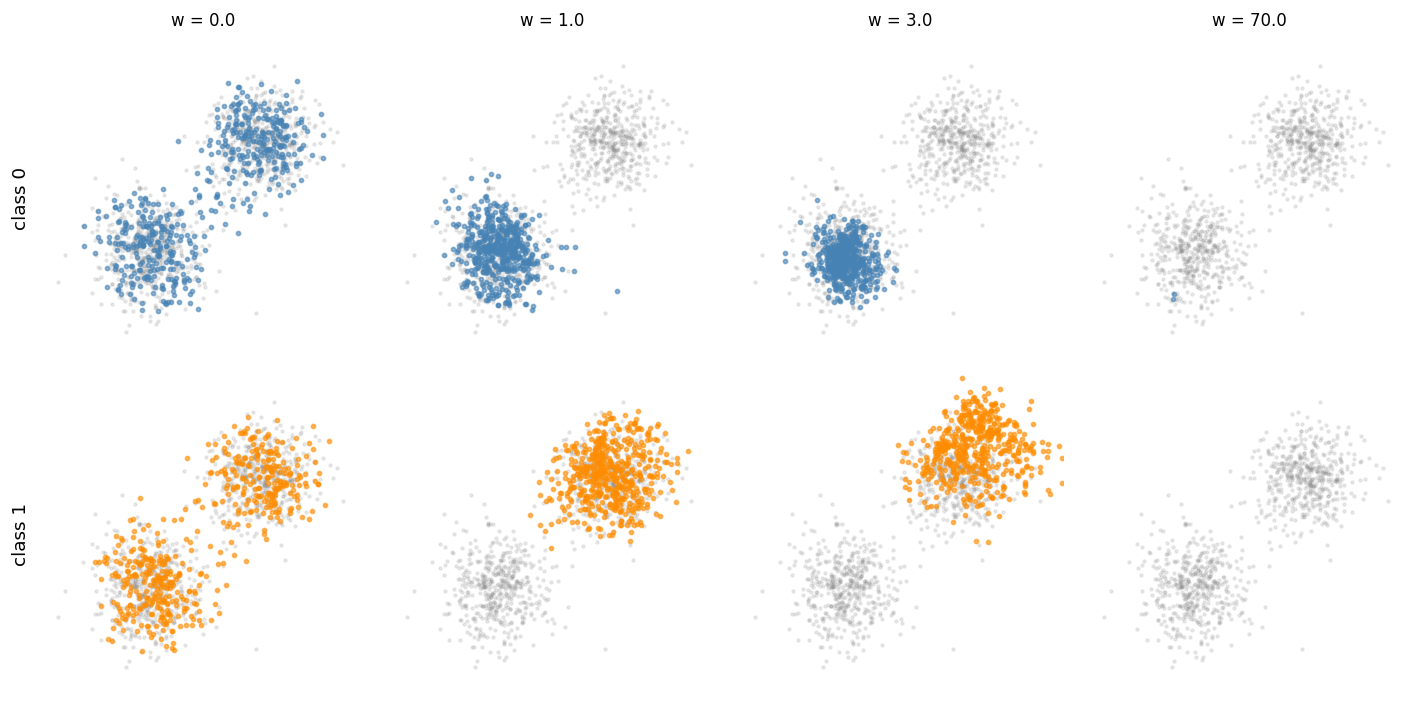

In [191]:
w_values = [0.0, 1.0, 3.0, 70.0]
classes  = [0, 1]
colors   = ['steelblue', 'darkorange']

fig, axes = plt.subplots(len(classes), len(w_values),
                         figsize=(3 * len(w_values), 3 * len(classes)))

for i, c in enumerate(classes):
    for j, w in enumerate(w_values):
        ax = axes[i, j]
        samples = ddpm_sample_cfg(model_cfg, target_class=c, n_samples=500, w=w)
        ax.scatter(X[:, 0], X[:, 1], s=3, alpha=0.15, color='gray')
        ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.6, color=colors[i])
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal'); ax.axis('off')
        if i == 0:
            ax.set_title(f'w = {w}', fontsize=10)
        if j == 0:
            ax.text(-3.2, 0, f'class {c}', rotation=90,
                    va='center', ha='right', fontsize=11)

plt.tight_layout(); plt.show()